# Notebook 03 — ARMA Order Selection

Determines discrete-time ARMA$(p,q)$ orders for deseasonalized temperature and log-price residuals by AIC minimization over a grid of $(p,q)$ pairs with $p \in \{1,\ldots,5\}$, $q \in \{0,\ldots,4\}$, $q < p$. Selected orders are **temperature: ARMA$(2,1)$** and **log-price: ARMA$(3,2)$**. These discrete orders map directly to the continuous-time CARMA dimensions: CARMA$(2,1)$ for temperature (notebook 06) and CARMA$(3,2)$ for log-price (notebook 07).

**Inputs:** `data/deseasonalised/temp_resid.csv`, `data/deseasonalised/price_resid_dejumped.csv`  
**Outputs:** none (orders passed manually to later notebooks)

### Data loading

Reads the deseasonalized residual series produced by notebook 02. Temperature residuals are stored in `temp_resid.csv` (column `temp_deseasoned`); log-price residuals in `price_resid_dejumped.csv` (column `y_dejumped_interp`).

In [1]:
import pandas as pd

temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res = temp_resid["temp_deseasoned"].copy()
time_temp = temp_res.index.copy()

price_resid = pd.read_csv("../data/deseasonalised/price_resid_dejumped.csv", index_col=0)
price_res = price_resid["y_dejumped_interp"].copy()
time_price = price_res.index.copy()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\ar_model.py:2108: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  full_mod = AutoReg(
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\ar_model.py:2185: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  mod = AutoReg(


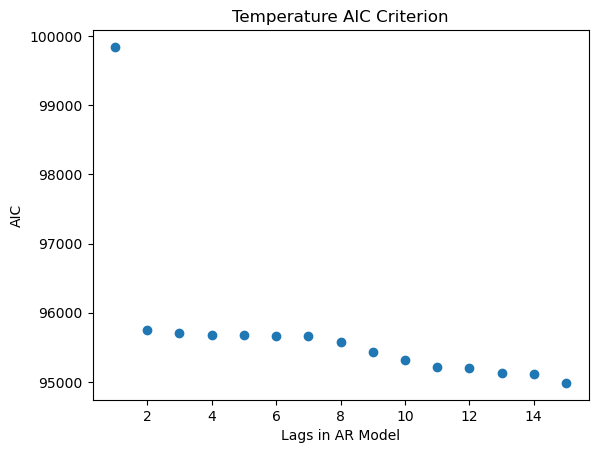

In [2]:
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import ar_select_order

residuals = temp_resid.copy(deep=True)
mod = ar_select_order(residuals, maxlag=15, ic='aic', old_names=True)

aic = []
for key, val in mod.aic.items():
    if key != 0:
        aic.append((key[-1], val))

aic.sort()
x,y = [x for x,y in aic],[y for x,y in aic]

plt.scatter(x, y)
plt.title("Temperature AIC Criterion")
plt.xlabel("Lags in AR Model")
plt.ylabel("AIC")
plt.show()

### Step 1 — Preliminary AR order selection

A quick scan over AR$(p)$ models using `ar_select_order` (AIC) to determine a reasonable AR lag range before the full ARMA grid search below.

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import ar_select_order

residuals = price_resid["y_dejumped_interp"].copy()
mod = ar_select_order(residuals, maxlag=15, ic='aic', old_names=True)

aic = []
for key, val in mod.aic.items():
    if key != 0:
        aic.append((key[-1], val))

aic.sort()
x, y = [x for x, y in aic], [y for x, y in aic]

plt.scatter(x, y)
plt.title("Log-price AIC criterion — AR(p) models")
plt.xlabel("Lags in AR model (p)")
plt.ylabel("AIC")
plt.show()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information

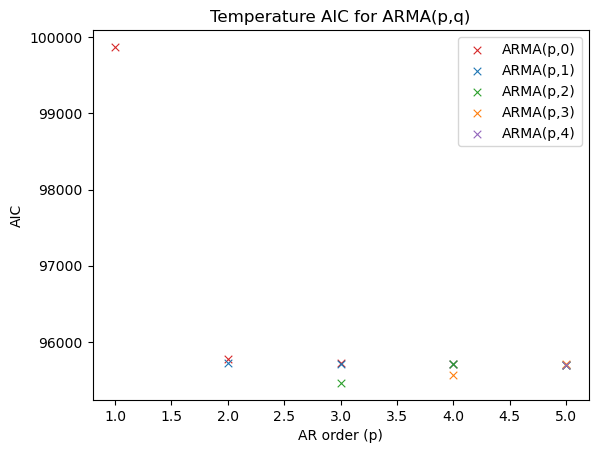

In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

residuals = temp_resid.copy(deep=True)

p_values0=range(1,6)
p_values1=range(2,6)
p_values2 = range(3, 6)
p_values3=range(4,6)
p_values4=range(5,6)

aic_values_temp0=[]
#(1,0)(2,0)(3,0)(4,0)(5,0)
aic_values_temp1=[]
#(2,1)(3,1)(4,1)(5,1)
aic_values_temp2=[]
#(3,2)(4,2)(5,2)
aic_values_temp3=[]
#+(4,3)(5,3)
aic_values_temp4=[]
#(5,4)

for p in p_values0:
    model = ARIMA(residuals, order=(p,0,0))
    result = model.fit()
    aic_values_temp0.append(result.aic)

for p in p_values1:
    model = ARIMA(residuals, order=(p,0,1))
    result = model.fit()
    aic_values_temp1.append(result.aic)

for p in p_values2:
    model = ARIMA(residuals, order=(p,0,2))
    result = model.fit()
    aic_values_temp2.append(result.aic)

for p in p_values3:
    model = ARIMA(residuals, order=(p,0,3))
    result = model.fit()
    aic_values_temp3.append(result.aic)

for p in p_values4:
    model = ARIMA(residuals, order=(p,0,4))
    result = model.fit()
    aic_values_temp4.append(result.aic)

plt.scatter(p_values0, aic_values_temp0, marker='x', s=30, linewidths=0.8, color='tab:red', label='ARMA(p,0)')
plt.scatter(p_values1, aic_values_temp1, marker='x', s=30, linewidths=0.8, color='tab:blue', label='ARMA(p,1)')
plt.scatter(p_values2, aic_values_temp2, marker='x', s=30, linewidths=0.8, color='tab:green', label='ARMA(p,2)')
plt.scatter(p_values3, aic_values_temp3, marker='x', s=30, linewidths=0.8, color='tab:orange', label='ARMA(p,3)')
plt.scatter(p_values4, aic_values_temp4, marker='x', s=30, linewidths=0.8, color='tab:purple', label='ARMA(p,4)')

plt.legend()
plt.title("Temperature AIC for ARMA(p,q)")
plt.xlabel("AR order (p)")
plt.ylabel("AIC")

plt.show()

### Step 2 — ARMA$(p,q)$ grid search (AIC)

Fits ARMA$(p,q)$ for all pairs with $p \in \{1,\ldots,5\}$, $q < p$. AIC is plotted by AR order $p$, with separate series for each MA order $q$. The minimum AIC determines the selected model.

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information

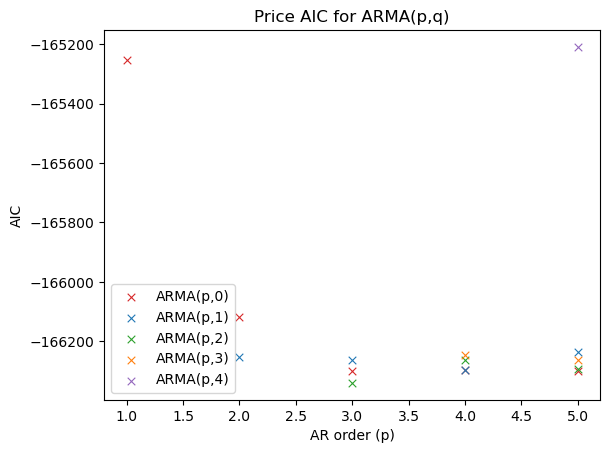

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

residuals = price_res.copy(deep=True)

p_values0=range(1,6)
p_values1=range(2,6)
p_values2 = range(3, 6)
p_values3=range(4,6)
p_values4=range(5,6)

aic_values_price0=[]
#(1,0)(2,0)(3,0)(4,0)(5,0)
aic_values_price1=[]
#(2,1)(3,1)(4,1)(5,1)
aic_values_price2=[]
#(3,2)(4,2)(5,2)
aic_values_price3=[]
#+(4,3)(5,3)
aic_values_price4=[]
#(5,4)

for p in p_values0:
    model = ARIMA(residuals, order=(p,0,0))
    result = model.fit()
    aic_values_price0.append(result.aic)

for p in p_values1:
    model = ARIMA(residuals, order=(p,0,1))
    result = model.fit()
    aic_values_price1.append(result.aic)

for p in p_values2:
    model = ARIMA(residuals, order=(p,0,2))
    result = model.fit()
    aic_values_price2.append(result.aic)

for p in p_values3:
    model = ARIMA(residuals, order=(p,0,3))
    result = model.fit()
    aic_values_price3.append(result.aic)

for p in p_values4:
    model = ARIMA(residuals, order=(p,0,4))
    result = model.fit()
    aic_values_price4.append(result.aic)

plt.scatter(p_values0, aic_values_price0, marker='x', s=30, linewidths=0.8, color='tab:red', label='ARMA(p,0)')
plt.scatter(p_values1, aic_values_price1, marker='x', s=30, linewidths=0.8, color='tab:blue', label='ARMA(p,1)')
plt.scatter(p_values2, aic_values_price2, marker='x', s=30, linewidths=0.8, color='tab:green', label='ARMA(p,2)')
plt.scatter(p_values3, aic_values_price3, marker='x', s=30, linewidths=0.8, color='tab:orange', label='ARMA(p,3)')
plt.scatter(p_values4, aic_values_price4, marker='x', s=30, linewidths=0.8, color='tab:purple', label='ARMA(p,4)')

plt.legend()
plt.title("Price AIC for ARMA(p,q)")
plt.xlabel("AR order (p)")
plt.ylabel("AIC")

plt.show()

### Step 3 — Fit selected models and display summaries

Temperature → ARMA$(2,1)$, Log-price → ARMA$(3,2)$.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

temp_residuals = temp_res.copy()
temp_model = ARIMA(temp_residuals, order=(2,0,1))
temp_result = temp_model.fit()


c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


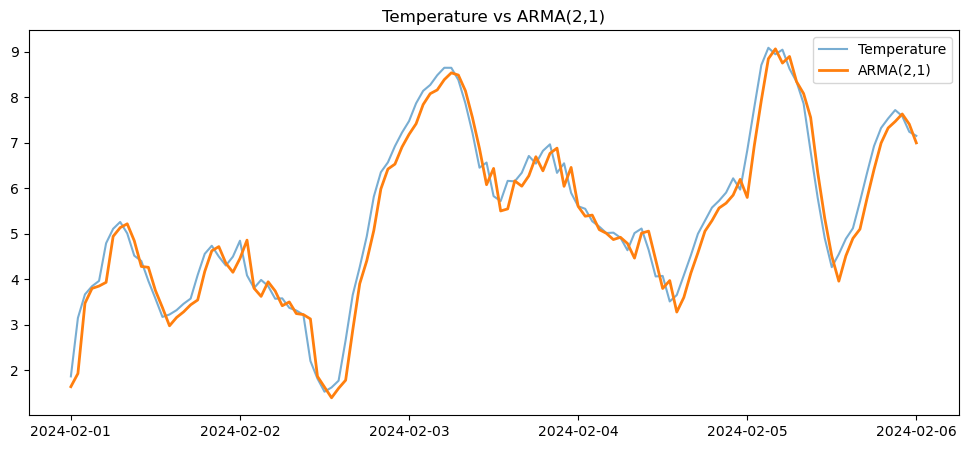

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_temp = pd.to_datetime(time_temp, errors="coerce").to_numpy(dtype="datetime64[ns]")
y_fit_temp = np.asarray(temp_result.fittedvalues, dtype=float)
y_res_temp = np.asarray(temp_res, dtype=float)

start_zoom = np.datetime64("2024-02-01")
end_zoom = np.datetime64("2024-02-06")

mask = (x_temp >= start_zoom) & (x_temp <= end_zoom)

plt.figure(figsize=(12, 5))
plt.plot(x_temp[mask], y_res_temp[mask], label="Temperature", alpha=0.6)
plt.plot(x_temp[mask], y_fit_temp[mask], label="ARMA(2,1)", linewidth=2)

plt.legend()
plt.title("Temperature vs ARMA(2,1)")
plt.show()

In [8]:
temp_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        temp_deseasoned   No. Observations:                52608
Model:                 ARIMA(2, 0, 1)   Log Likelihood              -48514.869
Date:                Sun, 29 Mar 2026   AIC                          97039.738
Time:                        11:48:32   BIC                          97084.091
Sample:                    01-01-2020   HQIC                         97053.598
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.146      0.007      0.995      -0.285       0.287
ar.L1          1.4061      0.011    132.559      0.000       1.385       1.427
ar.L2         -0.4228      0.010    -40.357      0.000      -0.443      -0.402
ma.L1         -0.1383      0.011    -12.901      0.000      -0.159      -0.117
sigma2         0.3703      0.001    332.668      0.000       0.368       0.372
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):            163424.53
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               0.83   Skew:                            -0.86
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

price_residuals = price_res.copy()
price_model = ARIMA(price_residuals, order=(3,0,2))
price_result = price_model.fit()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_price = pd.to_datetime(time_price, errors="coerce").to_numpy(dtype="datetime64[ns]")
y_fit_price = np.asarray(price_result.fittedvalues, dtype=float)
y_res_price = np.asarray(price_res, dtype=float)

start_zoom = np.datetime64("2024-09-01")
end_zoom   = np.datetime64("2024-09-10")
mask = (x_price >= start_zoom) & (x_price <= end_zoom)

plt.figure(figsize=(15, 5))
plt.plot(x_price[mask], y_res_price[mask], label="Log-price residual", alpha=0.6)
plt.plot(x_price[mask], y_fit_price[mask], label="ARMA(3,2) fit",      linewidth=2)
plt.legend()
plt.title("Log-price residuals vs ARMA(3,2) — zoom Sept 2024")
plt.xlabel("Date")
plt.ylabel("Log-price residual")
plt.show()

In [3]:
price_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      y_dejumped_interp   No. Observations:                26281
Model:                 ARIMA(3, 0, 2)   Log Likelihood               83177.116
Date:                Tue, 21 Apr 2026   AIC                        -166340.233
Time:                        14:22:39   BIC                        -166282.997
Sample:                    01-01-2023   HQIC                       -166321.752
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0007      0.001     -0.763      0.445      -0.003       0.001
ar.L1          1.5019      0.069     21.878      0.000       1.367       1.636
ar.L2         -0.5348      0.057     -9.345      0.000      -0.647      -0.423
ar.L3          0.0038      0.030      0.123      0.902      -0.056       0.064
ma.L1         -0.3795      0.069     -5.516      0.000      -0.514      -0.245
ma.L2         -0.1801      0.041     -4.357      0.000      -0.261      -0.099
sigma2         0.0001   4.73e-07    220.386      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.35   Jarque-Bera (JB):             44813.70
Prob(Q):                              0.55   Prob(JB):                         0.00
Heteroskedasticity (H):               1.61   Skew:                             0.07
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""